[INFO] Using device: cuda

 Replicate 1/10
Epoch   5 | Loss=715.313110 | Kurtosis=13.840307
Epoch  10 | Loss=657.809204 | Kurtosis=12.849490
Epoch  15 | Loss=569.616943 | Kurtosis=9.846174
Epoch  20 | Loss=567.883057 | Kurtosis=9.147962
Epoch  25 | Loss=565.319153 | Kurtosis=9.518006
Epoch  30 | Loss=563.047913 | Kurtosis=7.321492
Epoch  35 | Loss=560.518982 | Kurtosis=6.431421
Epoch  40 | Loss=559.661987 | Kurtosis=5.833174
Epoch  45 | Loss=556.531372 | Kurtosis=4.683500
Epoch  50 | Loss=555.981995 | Kurtosis=4.357835
Epoch  55 | Loss=555.017151 | Kurtosis=4.221409
Epoch  60 | Loss=554.404236 | Kurtosis=3.992428
Epoch  65 | Loss=553.850830 | Kurtosis=4.024016
Epoch  70 | Loss=551.575928 | Kurtosis=3.821796
Epoch  75 | Loss=551.003418 | Kurtosis=3.846346
Epoch  80 | Loss=551.705872 | Kurtosis=3.927083
Epoch  85 | Loss=550.078491 | Kurtosis=3.856490
Epoch  90 | Loss=550.715759 | Kurtosis=3.805524
Epoch  95 | Loss=550.178650 | Kurtosis=3.960679
Epoch 100 | Loss=548.598816 | Kurtosis=3.90

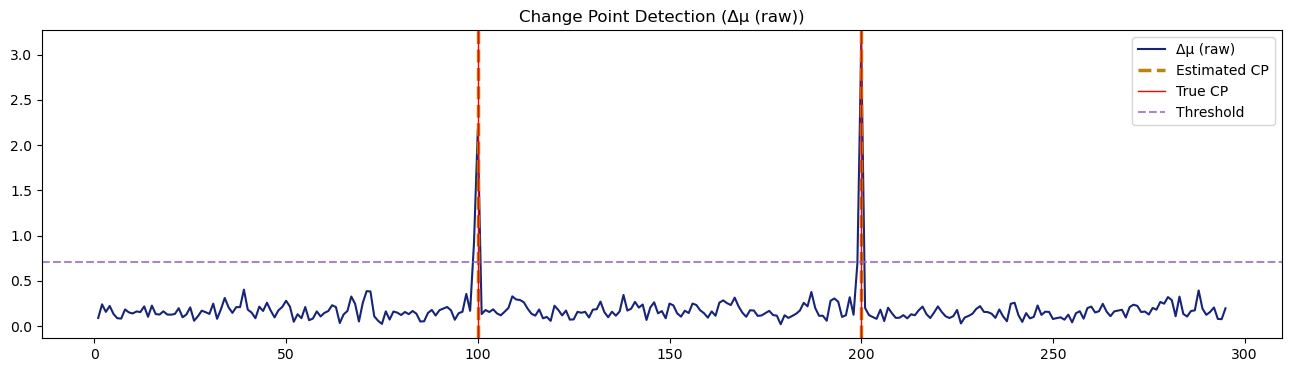

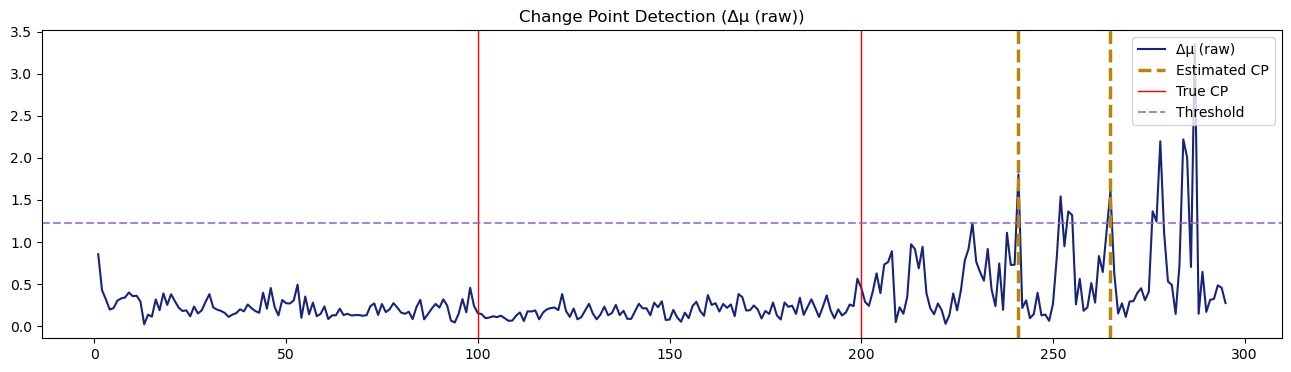

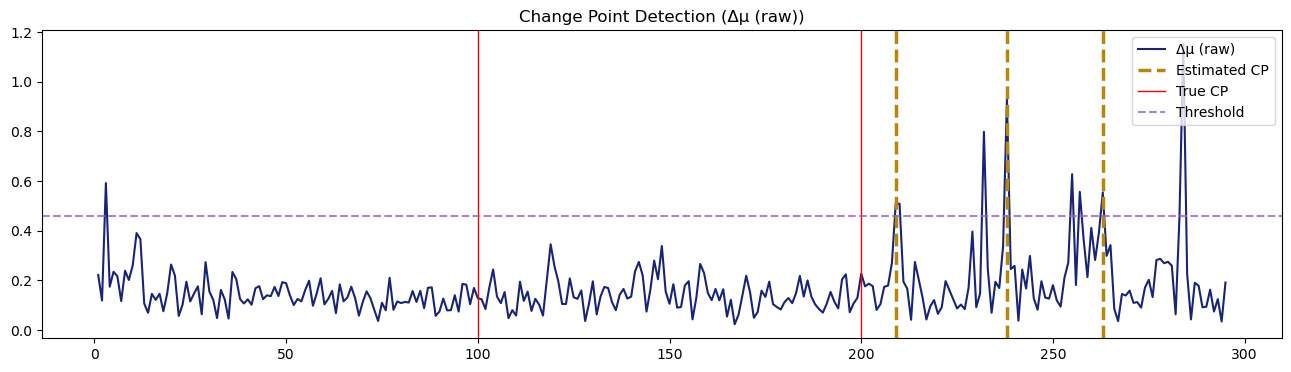

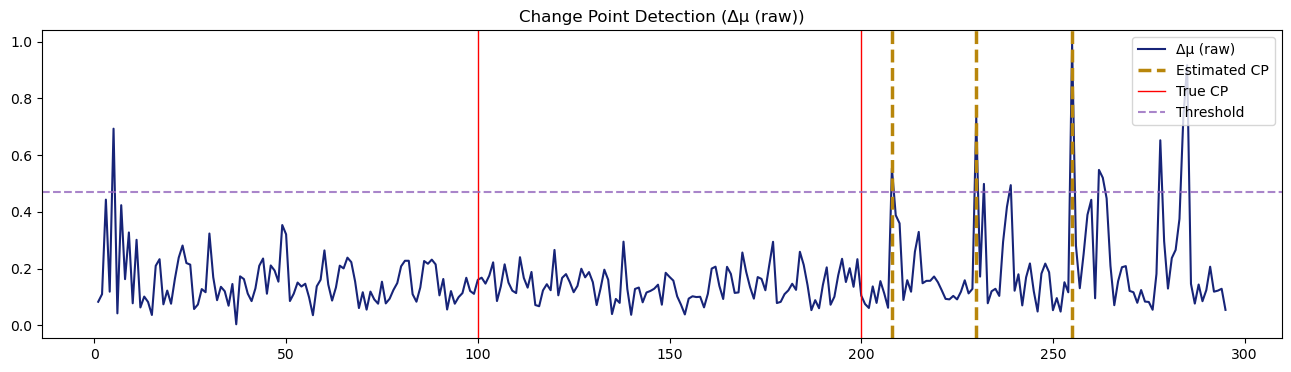

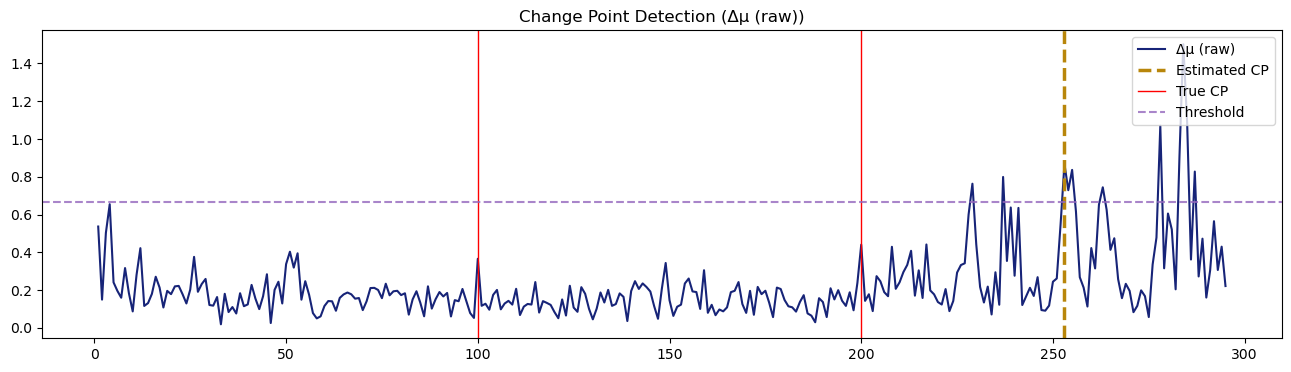

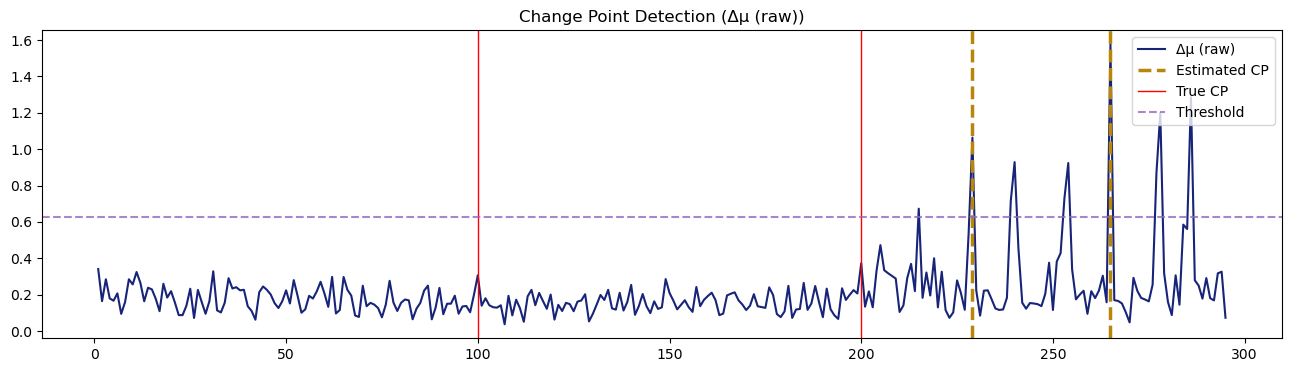

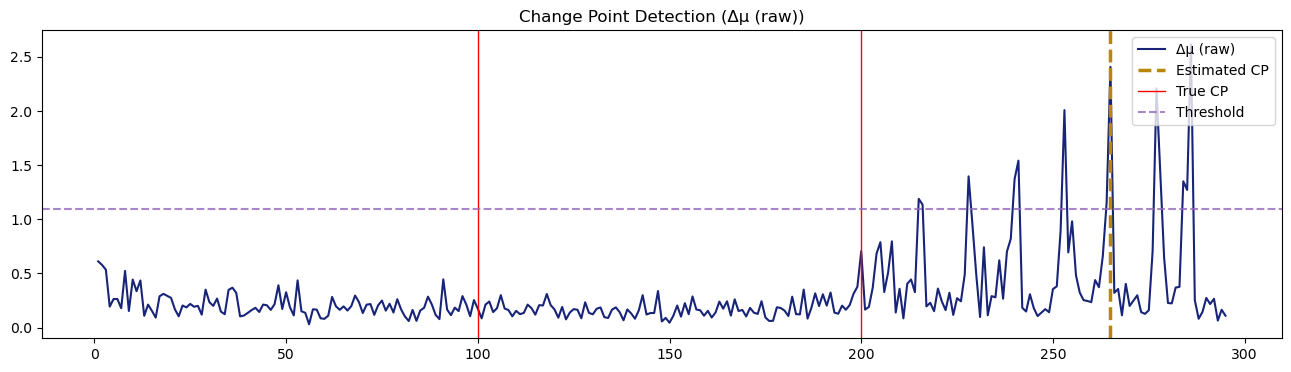

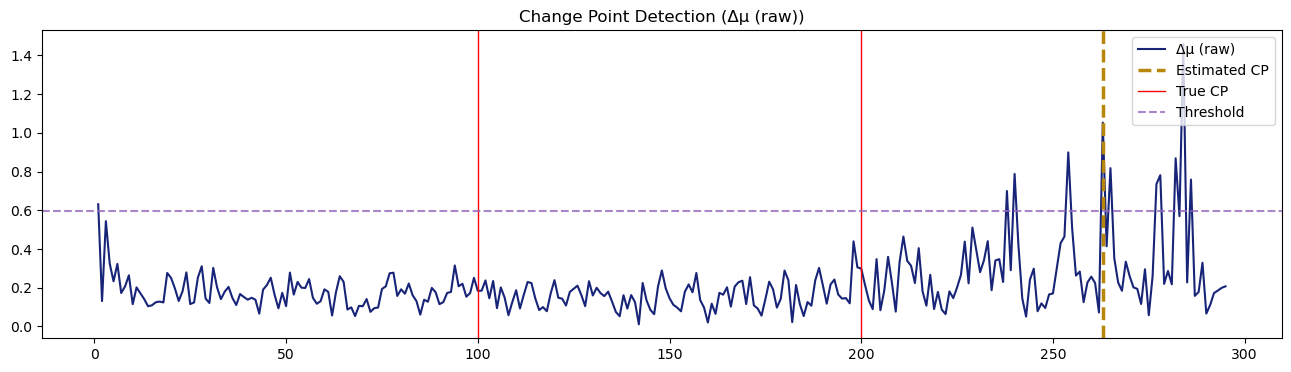

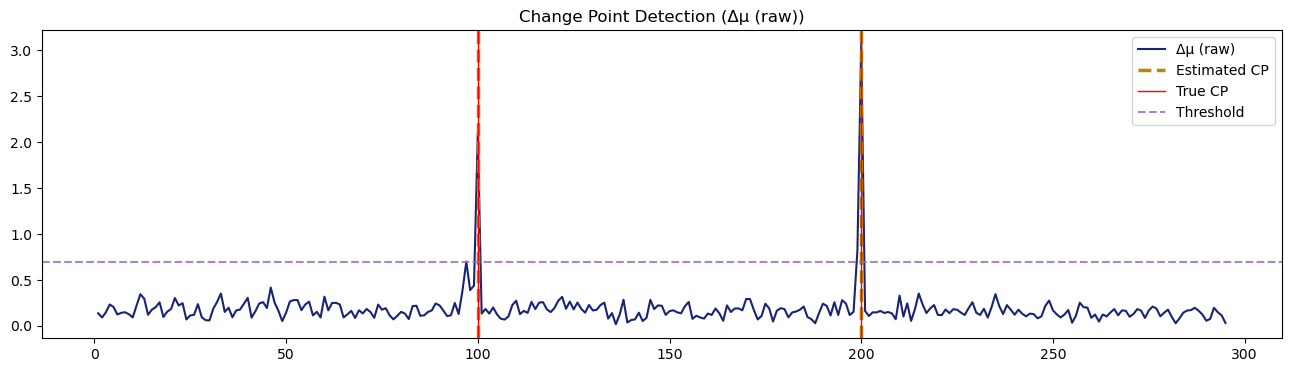

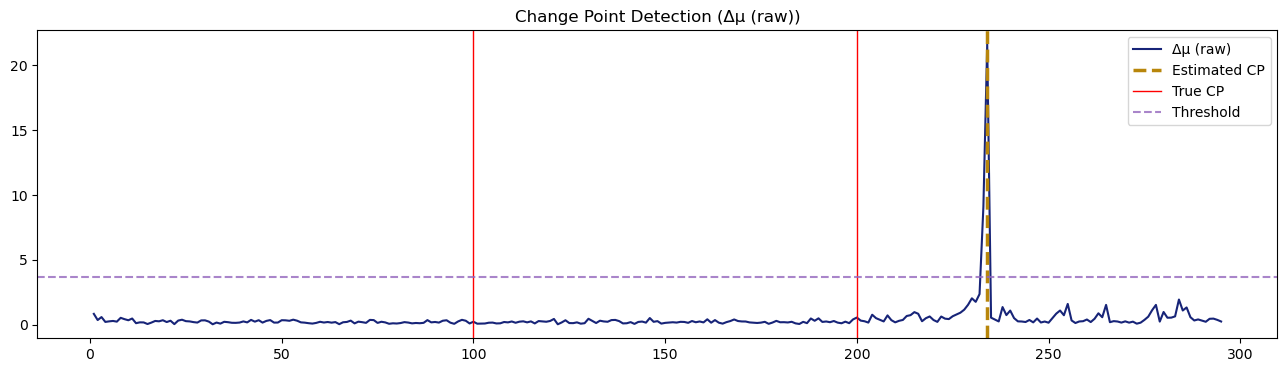

In [1]:
import torch, random, io, sys, warnings
import os, numpy as np, pandas as pd, pyreadr
from tqdm import tqdm

import sys, os
sys.path.append(os.path.abspath(".."))

from cpd_model_linear import parse_args, learn_one_seq_penalty

warnings.filterwarnings("ignore")

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":16:8"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Using device: {device}")

# ======================================================
# CONFIG
# ======================================================
REPS = 10
TRUE_CP = [100, 200]
TOL = 10

# ======================================================
# BASE ARGS
# ======================================================
base_args = parse_args()
base_args.epoch = 150
base_args.K_dim = 2
base_args.z_dim = 3
base_args.decoder_lr = 0.01
base_args.decoder_iteration = 20
base_args.langevin_s = 0.2
base_args.langevin_K = 100
base_args.kappa = 0.8
base_args.penalties = [0.01, 0.05, 0.1, 1]
base_args.nu_iteration = 20
base_args.output_layer = [50, 50] 
base_args.scale_delta = False
base_args.signif_level = 0.99
base_args.true_CP_full = TRUE_CP

# ======================================================
# MAIN LOOP（只 loop replicate）
# ======================================================
records = []

GLOBAL_SEED = 1

for rep in range(1, REPS + 1):

    print(f"\n==============================")
    print(f" Replicate {rep}/{REPS}")
    print(f"==============================")

    # ---------- seed ----------
    SEED = GLOBAL_SEED + rep
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

    # ---------- load data ----------
    Y = pyreadr.read_r(f"../real_data_sim/sim_dat_ult_5_{rep}.RDS")
    X = pyreadr.read_r(f"../real_data_sim/sim_x_ult_5_{rep}.RDS")

    Y_df = np.array(list(Y.values())[0])
    X_df = np.array(list(X.values())[0])

    # expand X
    X_rep = np.repeat(X_df[:, np.newaxis, :], 100, axis=1)
    Y = Y_df[:, :, 0:3]
    X = X_rep

    # ---------- args ----------
    args = parse_args()
    args.__dict__.update(base_args.__dict__)

    args.x_dim = X.shape[2]
    args.y_dim = Y.shape[2]
    args.num_time = X.shape[0]
    args.num_samples = X.shape[1]

    # ---------- tensor ----------
    x_input = torch.tensor(X, dtype=torch.float32).to(device)
    y_input = torch.tensor(Y, dtype=torch.float32).to(device)

    # ---------- split (CV) ----------
    odd_idx = range(1, args.num_time, 2)
    even_idx = range(0, args.num_time, 2)

    x_train = x_input[odd_idx].reshape(-1, args.x_dim)
    x_test  = x_input[even_idx].reshape(-1, args.x_dim)
    y_train = y_input[odd_idx].reshape(-1, args.y_dim)
    y_test  = y_input[even_idx].reshape(-1, args.y_dim)

    # ======================================================
    # penalty selection
    # ======================================================
    results_half = []

    for penalty in args.penalties:
        try:
            loss, _ = learn_one_seq_penalty(
                args, x_train, y_train, x_test, y_test,
                penalty=penalty, half=True
            )
        except:
            loss = np.inf

        results_half.append(loss)

    best_penalty = args.penalties[int(np.argmin(results_half))]
    print(f"[INFO] Best penalty = {best_penalty}")

    # ======================================================
    # full training
    # ======================================================
    try:
        out = learn_one_seq_penalty(
            args,
            x_input.reshape(-1, args.x_dim),
            y_input.reshape(-1, args.y_dim),
            x_input.reshape(-1, args.x_dim),
            y_input.reshape(-1, args.y_dim),
            penalty=best_penalty,
            half=False
        )
        result = out[0]
    except:
        print("[WARN] training failed")
        continue

    torch.cuda.empty_cache()

    # ======================================================
    # evaluation
    # ======================================================
    est_cp = np.array(result[5], dtype=int) if len(result[5]) > 0 else np.array([])
    true_cp = np.array(TRUE_CP)

    if len(est_cp) == 0:
        cover_rate = 0
        avg_dist = np.nan
        FP = 0
        FN = len(true_cp)
    else:
        dist_mat = np.abs(est_cp[:, None] - true_cp[None, :])
        min_dist_true = dist_mat.min(axis=0)
        min_dist_est  = dist_mat.min(axis=1)

        cover_rate = np.mean(min_dist_true <= TOL)
        avg_dist   = np.mean(min_dist_true)
        FP = np.sum(min_dist_est > TOL)
        FN = np.sum(min_dist_true > TOL)

    # ======================================================
    # record
    # ======================================================
    records.append({
        "rep": rep,
        "best_penalty": best_penalty,
        "num_detected": len(est_cp),

        "est_CP": str(list(est_cp)),
        "true_CP": str(TRUE_CP),

        "FP": FP,
        "FN": FN,
        "CR": cover_rate,
        "Dist": avg_dist,

        "CE": result[0],
    })

# ======================================================
# SAVE
# ======================================================
df = pd.DataFrame(records)
df.to_csv("cpd_linear_ablation_10.csv", index=False)

print("\n✅ Done. Saved to cpd_linear_ablation_10.csv")

In [16]:
import numpy as np
import pandas as pd
import ast
import re

# =====================================================
# CONFIG
# =====================================================
CSV_PATH = "cpd_linear_ablation_10.csv"
TRUE_CP = [100, 200]
TOL = 10
T = 296


# =====================================================
# parse est_CP（修 np.int64）
# =====================================================
def parse_cp(x):
    if pd.isna(x):
        return []

    s = str(x).strip()
    s = re.sub(r"np\.int64\((\d+)\)", r"\1", s)

    try:
        return list(ast.literal_eval(s))
    except:
        return []


# =====================================================
# evaluation（完全复用你最开始那套）
# =====================================================
def evaluate_cp(est_cp, true_cp, tol, T):
    est_cp = np.array(est_cp, dtype=int)
    true_cp = np.array(true_cp, dtype=int)

    if len(est_cp) == 0:
        FP = 0
        FN = len(true_cp)
        Dt_e = np.inf
        De_t = np.inf
        CE = abs(len(est_cp) - len(true_cp))
        CS = 0.0
        return FP, FN, Dt_e, De_t, CE, CS

    dist_mat = np.abs(est_cp[:, None] - true_cp[None, :])

    min_dist_true = dist_mat.min(axis=0)
    min_dist_est  = dist_mat.min(axis=1)

    FP = np.sum(min_dist_est > tol)
    FN = np.sum(min_dist_true > tol)

    Dt_e = np.max(min_dist_true)
    De_t = np.max(min_dist_est)

    CE = abs(len(est_cp) - len(true_cp))

    # segmentation score
    def get_segments(cp, T):
        cp = np.sort(cp)
        segs = []
        prev = 0
        for c in cp:
            segs.append(set(range(prev, c)))
            prev = c
        segs.append(set(range(prev, T)))
        return segs

    def jaccard(A, B):
        return len(A & B) / len(A | B) if len(A | B) > 0 else 0

    G  = get_segments(true_cp, T)
    Gp = get_segments(est_cp, T)

    CS = 0
    for A in G:
        best = max(jaccard(A, Ap) for Ap in Gp)
        CS += len(A) * best
    CS /= T

    return FP, FN, Dt_e, De_t, CE, CS


# =====================================================
# LOAD
# =====================================================
df = pd.read_csv(CSV_PATH)

df["est_CP"] = df["est_CP"].apply(parse_cp)

# =====================================================
# RECOMPUTE ALL METRICS
# =====================================================
metrics = df["est_CP"].apply(
    lambda cp: evaluate_cp(cp, TRUE_CP, TOL, T)
)

metrics_df = pd.DataFrame(
    metrics.tolist(),
    columns=["FP", "FN", "Dt_e", "De_t", "CE", "CS"]
)

df = df.drop(columns=["FP","FN","Dt_e","De_t","CE","CS"], errors="ignore")

df = pd.concat([df, metrics_df], axis=1)



summary = (
    df[["FP","FN","Dt_e","De_t","CE","CS"]]
    .mean()
    .round(2)
)

print("\n===== OVERALL MEAN =====\n")
print(summary)

# =====================================================
# LOAD NN RESULTS
# =====================================================
NN_PATH = "../combined_clean_results.csv"

df_nn_all = pd.read_csv(NN_PATH)

df_nn = (
    df_nn_all[df_nn_all["method"] == "cpd_nn"]
    .head(10)
    .copy()
)
df_nn = df_nn.rename(columns={
    "abs_error": "CE",
    "dist_est_gt": "De_t",
    "dist_gt_est": "Dt_e",
    "covering_metric": "CS"
})
nn_summary = (
    df_nn[["FP","FN","Dt_e","De_t","CE","CS"]]
    .mean()
    .round(2)
)

print("\n===== NN (cpd_nn) MEAN =====\n")
print(nn_summary)

metrics = ["FP","FN","Dt_e","De_t","CE","CS"]

# Linear
summary_mean = df[metrics].mean()
summary_sd   = df[metrics].std()

# NN
nn_mean = df_nn[metrics].mean()
nn_sd   = df_nn[metrics].std()

comparison_df = pd.DataFrame({
    "Model": ["Linear", "NN"]
})

for m in metrics:
    comparison_df[f"{m}_mean"] = [summary_mean[m], nn_mean[m]]
    comparison_df[f"{m}_sd"]   = [summary_sd[m], nn_sd[m]]

comparison_df = comparison_df.round(3)

def to_latex_two_rows(df):

    metrics = ["FP","FN","Dt_e","De_t","CE","CS"]

    best = {
        "FP": df["FP_mean"].min(),
        "FN": df["FN_mean"].min(),
        "Dt_e": df["Dt_e_mean"].min(),
        "De_t": df["De_t_mean"].min(),
        "CE": df["CE_mean"].min(),
        "CS": df["CS_mean"].max(),
    }

    def bold(val, best_val):
        if val == best_val:
            return f"\\textbf{{{val:.3f}}}"
        return f"{val:.3f}"

    latex = []
    latex.append("\\begin{table}[!ht]")
    latex.append("\\caption{Comparison between linear ablation and NN model.}")
    latex.append("\\label{tab:linear_vs_nn}")
    latex.append("\\centering")
    latex.append("\\small")
    latex.append("\\begin{tabular}{lcccccc}")
    latex.append("\\toprule")
    latex.append("Method & FP$\\downarrow$ & FN$\\downarrow$ & $D_{t\\to e}$ & $D_{e\\to t}$ & CE$\\downarrow$ & CS$\\uparrow$ \\\\")
    latex.append("\\midrule")

    for _, r in df.iterrows():

        mean_vals = [
            bold(r["FP_mean"], best["FP"]),
            bold(r["FN_mean"], best["FN"]),
            bold(r["Dt_e_mean"], best["Dt_e"]),
            bold(r["De_t_mean"], best["De_t"]),
            bold(r["CE_mean"], best["CE"]),
            bold(r["CS_mean"], best["CS"]),
        ]

        latex.append(
            f"{r['Model']} & " + " & ".join(mean_vals) + " \\\\"
        )

        sd_vals = [
            f"({r['FP_sd']:.3f})",
            f"({r['FN_sd']:.3f})",
            f"({r['Dt_e_sd']:.3f})",
            f"({r['De_t_sd']:.3f})",
            f"({r['CE_sd']:.3f})",
            f"({r['CS_sd']:.3f})",
        ]

        latex.append(
            " & " + " & ".join(sd_vals) + " \\\\"
        )

    latex.append("\\bottomrule")
    latex.append("\\end{tabular}")
    latex.append("\\end{table}")

    return "\n".join(latex)
latex_table = to_latex_two_rows(comparison_df)

print("\n===== LaTeX Table =====\n")
print(latex_table)


===== OVERALL MEAN =====

FP        1.20
FN        1.40
Dt_e    110.20
De_t     46.30
CE        0.60
CS        0.53
dtype: float64

===== NN (cpd_nn) MEAN =====

FP       0.50
FN       0.00
Dt_e    36.50
De_t     0.00
CE       0.50
CS       0.96
dtype: float64

===== LaTeX Table =====

\begin{table}[!ht]
\caption{Comparison between linear ablation and NN model.}
\label{tab:linear_vs_nn}
\centering
\small
\begin{tabular}{lcccccc}
\toprule
Method & FP$\downarrow$ & FN$\downarrow$ & $D_{t\to e}$ & $D_{e\to t}$ & CE$\downarrow$ & CS$\uparrow$ \\
\midrule
Linear & 1.200 & 1.400 & 110.200 & 46.300 & 0.600 & 0.534 \\
 & (0.789) & (0.843) & (61.270) & (26.175) & (0.516) & (0.249) \\
NN & \textbf{0.500} & \textbf{0.000} & \textbf{36.500} & \textbf{0.000} & \textbf{0.500} & \textbf{0.957} \\
 & (0.527) & (0.000) & (38.492) & (0.000) & (0.527) & (0.046) \\
\bottomrule
\end{tabular}
\end{table}
